# Word Embeddings

Two routes to word vectors compared on the same words: a count-based co-occurrence matrix reduced with truncated SVD, and pre-trained GloVe embeddings. Then cosine similarity is used to probe what those vectors actually encode — polysemy, synonyms against antonyms, analogies, and gender bias.

Coursework for ICS472 (Natural Language Processing), KFUPM.

Requires `gensim` (`pip install -U gensim`).


In [1]:
pip install -U gensim

  Using cached wrapt-2.1.1-cp313-cp313-macosx_11_0_arm64.whl.metadata (7.4 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.4/24.4 MB 24.7 MB/s  0:00:01 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3/3 [gensim]2m2/3 [gensim]
Note: you may need to restart the kernel to use updated packages.


In [2]:
# All Import Statements Defined Here
# Note: Do not add to this list.

import sys
assert sys.version_info[0]==3
assert sys.version_info[1] >= 5

from platform import python_version
assert int(python_version().split(".")[1]) >= 5, "Please upgrade your Python version Your Python version is " + python_version()

from gensim.models import KeyedVectors
from gensim.test.utils import datapath
import pprint
import matplotlib.pyplot as plt
plt.rcParams['figure.figsize'] = [10, 5]
import nltk
nltk.download('reuters') #to specify download location, optionally add the argument: download_dir='/specify/desired/path/'
from nltk.corpus import reuters
import numpy as np
import random
import scipy as sp
from sklearn.decomposition import TruncatedSVD
from sklearn.decomposition import PCA

START_TOKEN = '<START>'
END_TOKEN = '<END>'

np.random.seed(0)
random.seed(0)
# ----------------

[nltk_data] Downloading package reuters to
[nltk_data]     /Users/mohammedalsheqaih/nltk_data...


## Word Vectors

Word Vectors are often used as a fundamental component for downstream NLP tasks, e.g. question answering, text generation, translation, etc., so it is important to build some intuitions as to their strengths and weaknesses. Here, you will explore two types of word vectors: those derived from *co-occurrence matrices*, and those derived via *GloVe*. 

**Note on Terminology:** The terms "word vectors" and "word embeddings" are often used interchangeably. The term "embedding" refers to the fact that we are encoding aspects of a word's meaning in a lower dimensional space. As [Wikipedia](https://en.wikipedia.org/wiki/Word_embedding) states, "*conceptually it involves a mathematical embedding from a space with one dimension per word to a continuous vector space with a much lower dimension*".

## Part 1: Count-based word vectors

Most word vector models start from one idea: *You shall know a word by the company it keeps* ([Firth, J. R. 1957:11](https://en.wikipedia.org/wiki/John_Rupert_Firth)). Words that appear in similar contexts tend to mean similar things, so counting contexts gives you a representation of meaning.


### Co-Occurrence

A co-occurrence matrix counts how often things co-occur in some environment. Given some word $w_i$ occurring in the document, we consider the *context window* surrounding $w_i$. Supposing our fixed window size is $n$, then this is the $n$ preceding and $n$ subsequent words in that document, i.e. words $w_{i-n} \dots w_{i-1}$ and $w_{i+1} \dots w_{i+n}$. We build a *co-occurrence matrix* $M$, which is a symmetric word-by-word matrix in which $M_{ij}$ is the number of times $w_j$ appears inside $w_i$'s window among all documents.

**Example: Co-Occurrence with Fixed Window of n=1**:

Document 1: "all that glitters is not gold"

Document 2: "all is well that ends well"

|     *    | `<START>` | all | that | glitters | is   | not  | gold  | well | ends | `<END>` |
|----------|-------|-----|------|----------|------|------|-------|------|------|-----|
| `<START>`    | 0     | 2   | 0    | 0        | 0    | 0    | 0     | 0    | 0    | 0   |
| all      | 2     | 0   | 1    | 0        | 1    | 0    | 0     | 0    | 0    | 0   |
| that     | 0     | 1   | 0    | 1        | 0    | 0    | 0     | 1    | 1    | 0   |
| glitters | 0     | 0   | 1    | 0        | 1    | 0    | 0     | 0    | 0    | 0   |
| is       | 0     | 1   | 0    | 1        | 0    | 1    | 0     | 1    | 0    | 0   |
| not      | 0     | 0   | 0    | 0        | 1    | 0    | 1     | 0    | 0    | 0   |
| gold     | 0     | 0   | 0    | 0        | 0    | 1    | 0     | 0    | 0    | 1   |
| well     | 0     | 0   | 1    | 0        | 1    | 0    | 0     | 0    | 1    | 1   |
| ends     | 0     | 0   | 1    | 0        | 0    | 0    | 0     | 1    | 0    | 0   |
| `<END>`      | 0     | 0   | 0    | 0        | 0    | 0    | 1     | 1    | 0    | 0   |

**Note:** In NLP, we often add `<START>` and `<END>` tokens to represent the beginning and end of sentences, paragraphs or documents. In this case we imagine `<START>` and `<END>` tokens encapsulating each document, e.g., "`<START>` All that glitters is not gold `<END>`", and include these tokens in our co-occurrence counts.

The rows (or columns) of this matrix provide one type of word vectors (those based on word-word co-occurrence), but the vectors will be large in general (linear in the number of distinct words in a corpus). Thus, our next step is to run *dimensionality reduction*. In particular, we will run *SVD (Singular Value Decomposition)*, which is a kind of generalized *PCA (Principal Components Analysis)* to select the top $k$ principal components. Here's a visualization of dimensionality reduction with SVD. In this picture our co-occurrence matrix is $A$ with $n$ rows corresponding to $n$ words. We obtain a full matrix decomposition, with the singular values ordered in the diagonal $S$ matrix, and our new, shorter length-$k$ word vectors in $U_k$.

This reduced-dimensionality co-occurrence representation preserves semantic relationships between words, e.g. *doctor* and *hospital* will be closer than *doctor* and *dog*. 


### Plotting Co-Occurrence Word Embeddings

Here, we will be using the Reuters (business and financial news) corpus. If you haven't run the import cell at the top of this page, please run it now (click it and press SHIFT-RETURN). The corpus consists of 10,788 news documents totaling 1.3 million words. These documents span 90 categories and are split into train and test. For more details, please see https://www.nltk.org/book/ch02.html. We provide a `read_corpus` function below that pulls out only articles from the "crude" (i.e. news articles about oil, gas, etc.) category. The function also adds `<START>` and `<END>` tokens to each of the documents, and lowercases words. You do **not** have to perform any other kind of pre-processing.

In [12]:
def read_corpus(category="crude"): #we can replace by other categories such as "grain"
    """ Read files from the specified Reuter's category.
        Params:
            category (string): category name
        Return:
            list of lists, with words from each of the processed files
    """
    files = reuters.fileids(category)
    return [[START_TOKEN] + [w.lower() for w in list(reuters.words(f))] + [END_TOKEN] for f in files]

Let's have a look what these documents are like….

In [13]:
reuters_corpus = read_corpus()
pprint.pprint(reuters_corpus[:3], compact=True, width=100)

[['<START>', 'japan', 'to', 'revise', 'long', '-', 'term', 'energy', 'demand', 'downwards', 'the',
  'ministry', 'of', 'international', 'trade', 'and', 'industry', '(', 'miti', ')', 'will', 'revise',
  'its', 'long', '-', 'term', 'energy', 'supply', '/', 'demand', 'outlook', 'by', 'august', 'to',
  'meet', 'a', 'forecast', 'downtrend', 'in', 'japanese', 'energy', 'demand', ',', 'ministry',
  'officials', 'said', '.', 'miti', 'is', 'expected', 'to', 'lower', 'the', 'projection', 'for',
  'primary', 'energy', 'supplies', 'in', 'the', 'year', '2000', 'to', '550', 'mln', 'kilolitres',
  '(', 'kl', ')', 'from', '600', 'mln', ',', 'they', 'said', '.', 'the', 'decision', 'follows',
  'the', 'emergence', 'of', 'structural', 'changes', 'in', 'japanese', 'industry', 'following',
  'the', 'rise', 'in', 'the', 'value', 'of', 'the', 'yen', 'and', 'a', 'decline', 'in', 'domestic',
  'electric', 'power', 'demand', '.', 'miti', 'is', 'planning', 'to', 'work', 'out', 'a', 'revised',
  'energy', 'supply

### Distinct words

Working out the vocabulary: the sorted list of word types in the corpus, and its size.


In [14]:
def distinct_words(corpus):
    """ Determine a list of distinct words for the corpus.
        Params:
            corpus (list of list of strings): corpus of documents
        Return:
            corpus_words (list of strings): sorted list of distinct words across the corpus
            n_corpus_words (integer): number of distinct words across the corpus
    """
    corpus_words = []
    n_corpus_words = -1
    
    # 1 - Flattening the 2D list into a 1D list (list comprehension)
    # 2 - Converting to a set (removing duplicate words)
    # 3 - Sorting the resulting set (alphabetically)
    corpus_words = sorted(list(set([word for document in corpus for word in document])))

    # 4 - Total count of distinct words
    n_corpus_words = len(corpus_words)

    return corpus_words, n_corpus_words

In [15]:
# Note that this not an exhaustive check for correctness.

# Define toy corpus
test_corpus = ["{} All that glitters isn't gold {}".format(START_TOKEN, END_TOKEN).split(" "), "{} All's well that ends well {}".format(START_TOKEN, END_TOKEN).split(" ")]
test_corpus_words, num_corpus_words = distinct_words(test_corpus)

# Correct answers
ans_test_corpus_words = sorted([START_TOKEN, "All", "ends", "that", "gold", "All's", "glitters", "isn't", "well", END_TOKEN])
ans_num_corpus_words = len(ans_test_corpus_words)

# Test correct number of words
assert(num_corpus_words == ans_num_corpus_words), "Incorrect number of distinct words. Correct: {}. Yours: {}".format(ans_num_corpus_words, num_corpus_words)

# Test correct words
assert (test_corpus_words == ans_test_corpus_words), "Incorrect corpus_words.\nCorrect: {}\nYours:   {}".format(str(ans_test_corpus_words), str(test_corpus_words))

# Print Success
print ("-" * 80)
print("Passed All Tests!")
print ("-" * 80)

--------------------------------------------------------------------------------
Passed All Tests!
--------------------------------------------------------------------------------


### The co-occurrence matrix

Counting, for a window of size *n*, how often each word appears within *n* positions of each other word.


In [16]:
def compute_co_occurrence_matrix(corpus, window_size=4):
    """ Compute co-occurrence matrix for the given corpus and window_size (default of 4).
    
        Note: Each word in a document should be at the center of a window. Words near edges will have a smaller
              number of co-occurring words.
              
              For example, if we take the document "<START> All that glitters is not gold <END>" with window size of 4,
              "All" will co-occur with "<START>", "that", "glitters", "is", and "not".
    
        Params:
            corpus (list of list of strings): corpus of documents
            window_size (int): size of context window
        Return:
            M (a symmetric numpy matrix of shape (number of unique words in the corpus , number of unique words in the corpus)): 
                Co-occurence matrix of word counts. 
                The ordering of the words in the rows/columns should be the same as the ordering of the words given by the distinct_words function.
            word2ind (dict): dictionary that maps word to index (i.e. row/column number) for matrix M.
    """
    words, n_words = distinct_words(corpus)
    M = None
    word2ind = {}
    

    # 1 - Initializing the dictionary (mapping words)
    word2ind = {word: i for i, word in enumerate(words)}
    
    # 2 - Initializing the co-occurrence matrix M
    M = np.zeros((n_words, n_words))
    
    # 3 - Iterating through each document in corpus
    for document in corpus:
        doc_len = len(document)
        # Iterating through each word (acting as the center word)
        for i, center_word in enumerate(document):
            center_idx = word2ind[center_word]
            
            # Determining the window boundaries (so that we do not go out of bounds)
            start_idx = max(0, i - window_size)
            end_idx = min(doc_len, i + window_size + 1)
            
            # Iterating through the context words within the window
            for j in range(start_idx, end_idx):
                if i != j: # Excluding the center word itself
                    context_word = document[j]
                    context_idx = word2ind[context_word]
                    
                    # Incrementing the co-occurrence count
                    M[center_idx, context_idx] += 1
    

    return M, word2ind

In [17]:
# Note that this is not an exhaustive check for correctness.

# Define toy corpus and get student's co-occurrence matrix
test_corpus = ["{} All that glitters isn't gold {}".format(START_TOKEN, END_TOKEN).split(" "), "{} All's well that ends well {}".format(START_TOKEN, END_TOKEN).split(" ")]
M_test, word2ind_test = compute_co_occurrence_matrix(test_corpus, window_size=1)

# Correct M and word2ind
M_test_ans = np.array( 
    [[0., 0., 0., 0., 0., 0., 1., 0., 0., 1.,],
     [0., 0., 1., 1., 0., 0., 0., 0., 0., 0.,],
     [0., 1., 0., 0., 0., 0., 0., 0., 1., 0.,],
     [0., 1., 0., 0., 0., 0., 0., 0., 0., 1.,],
     [0., 0., 0., 0., 0., 0., 0., 0., 1., 1.,],
     [0., 0., 0., 0., 0., 0., 0., 1., 1., 0.,],
     [1., 0., 0., 0., 0., 0., 0., 1., 0., 0.,],
     [0., 0., 0., 0., 0., 1., 1., 0., 0., 0.,],
     [0., 0., 1., 0., 1., 1., 0., 0., 0., 1.,],
     [1., 0., 0., 1., 1., 0., 0., 0., 1., 0.,]]
)
ans_test_corpus_words = sorted([START_TOKEN, "All", "ends", "that", "gold", "All's", "glitters", "isn't", "well", END_TOKEN])
word2ind_ans = dict(zip(ans_test_corpus_words, range(len(ans_test_corpus_words))))

# Test correct word2ind
assert (word2ind_ans == word2ind_test), "Your word2ind is incorrect:\nCorrect: {}\nYours: {}".format(word2ind_ans, word2ind_test)

# Test correct M shape
assert (M_test.shape == M_test_ans.shape), "M matrix has incorrect shape.\nCorrect: {}\nYours: {}".format(M_test.shape, M_test_ans.shape)

# Test correct M values
for w1 in word2ind_ans.keys():
    idx1 = word2ind_ans[w1]
    for w2 in word2ind_ans.keys():
        idx2 = word2ind_ans[w2]
        student = M_test[idx1, idx2]
        correct = M_test_ans[idx1, idx2]
        if student != correct:
            print("Correct M:")
            print(M_test_ans)
            print("Your M: ")
            print(M_test)
            raise AssertionError("Incorrect count at index ({}, {})=({}, {}) in matrix M. Yours has {} but should have {}.".format(idx1, idx2, w1, w2, student, correct))

# Print Success
print ("-" * 80)
print("Passed All Tests!")
print ("-" * 80)

--------------------------------------------------------------------------------
Passed All Tests!
--------------------------------------------------------------------------------


### Dimensionality reduction

The co-occurrence matrix is huge and sparse, so truncated SVD reduces it to *k* dimensions while keeping most of the variance.


In [18]:
def reduce_to_k_dim(M, k=2):
    """ Reduce a co-occurence count matrix of dimensionality (num_corpus_words, num_corpus_words)
        to a matrix of dimensionality (num_corpus_words, k) using the following SVD function from Scikit-Learn:
            - http://scikit-learn.org/stable/modules/generated/sklearn.decomposition.TruncatedSVD.html
    
        Params:
            M (numpy matrix of shape (number of unique words in the corpus , number of unique words in the corpus)): co-occurence matrix of word counts
            k (int): embedding size of each word after dimension reduction
        Return:
            M_reduced (numpy matrix of shape (number of corpus words, k)): matrix of k-dimensioal word embeddings.
                    In terms of the SVD from math class, this actually returns U * S
    """    
    n_iters = 10     # Use this parameter in your call to `TruncatedSVD`
    M_reduced = None
    print("Running Truncated SVD over %i words..." % (M.shape[0]))
    

    # Initializing the TruncatedSVD object with n_components=k and n_iter=n_iters
    svd = TruncatedSVD(n_components=k, n_iter=n_iters, random_state=42)
    
    # Fitting the model to the matrix M and perform dimensionality reduction
    M_reduced = svd.fit_transform(M)
    

    print("Done.")
    return M_reduced

In [19]:
# Note that this is not an exhaustive check for correctness 
# In fact we only check that your M_reduced has the right dimensions.

# Define toy corpus and run student code
test_corpus = ["{} All that glitters isn't gold {}".format(START_TOKEN, END_TOKEN).split(" "), "{} All's well that ends well {}".format(START_TOKEN, END_TOKEN).split(" ")]
M_test, word2ind_test = compute_co_occurrence_matrix(test_corpus, window_size=1)
M_test_reduced = reduce_to_k_dim(M_test, k=2)

# Test proper dimensions
assert (M_test_reduced.shape[0] == 10), "M_reduced has {} rows; should have {}".format(M_test_reduced.shape[0], 10)
assert (M_test_reduced.shape[1] == 2), "M_reduced has {} columns; should have {}".format(M_test_reduced.shape[1], 2)

# Print Success
print ("-" * 80)
print("Passed All Tests!")
print ("-" * 80)

Running Truncated SVD over 10 words...
Done.
--------------------------------------------------------------------------------
Passed All Tests!
--------------------------------------------------------------------------------


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/utils/extmath.py:351: RuntimeWarning: divide by zero encountered in matmul
  Q, _ = normalizer(A.T @ Q)
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/utils/extmath.py:351: RuntimeWarning: overflow encountered in matmul
  Q, _ = normalizer(A.T @ Q)
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/utils/extmath.py:351: RuntimeWarning: invalid value encountered in matmul
  Q, _ = normalizer(A.T @ Q)


### Plotting the embeddings

A scatter plot of the reduced 2D vectors for a chosen set of words.


In [20]:
def plot_embeddings(M_reduced, word2ind, words):
    """ Plot in a scatterplot the embeddings of the words specified in the list "words".
        NOTE: do not plot all the words listed in M_reduced / word2ind.
        Include a label next to each point.
        
        Params:
            M_reduced (numpy matrix of shape (number of unique words in the corpus , 2)): matrix of 2-dimensioal word embeddings
            word2ind (dict): dictionary that maps word to indices for matrix M
            words (list of strings): words whose embeddings we want to visualize
    """

    
    # Iterating through what we want to plot (specific words)
    for word in words:
        # Getting the index of the word to locate its embedding in M_reduced
        idx = word2ind[word]
        
        # Extracting the x and y coordinates (the 2 dimensions)
        x = M_reduced[idx, 0]
        y = M_reduced[idx, 1]
        
        plt.scatter(x, y, marker='x', color='red')
        
        plt.annotate(word, (x, y))
        
    plt.show()
    
    

    # ------------------

--------------------------------------------------------------------------------
Outputted Plot:


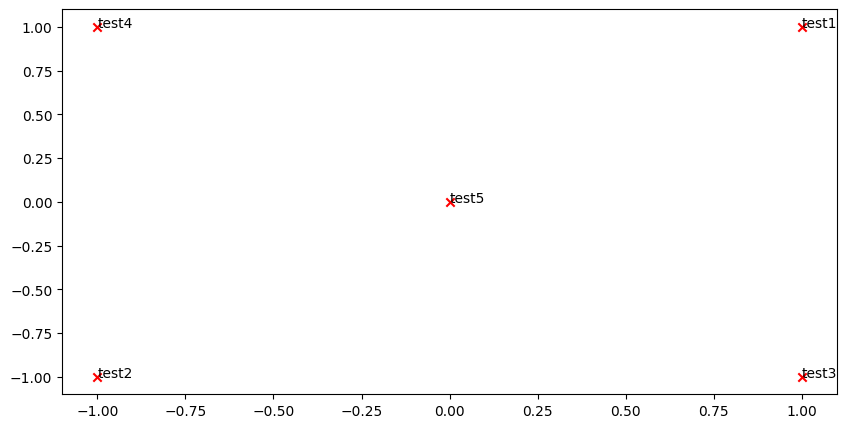

--------------------------------------------------------------------------------


In [21]:
# Note that this is not an exhaustive check for correctness.
# The plot produced should look like the "test solution plot" depicted below. 

print ("-" * 80)
print ("Outputted Plot:")

M_reduced_plot_test = np.array([[1, 1], [-1, -1], [1, -1], [-1, 1], [0, 0]])
word2ind_plot_test = {'test1': 0, 'test2': 1, 'test3': 2, 'test4': 3, 'test5': 4}
words = ['test1', 'test2', 'test3', 'test4', 'test5']
plot_embeddings(M_reduced_plot_test, word2ind_plot_test, words)

print ("-" * 80)

### Reading the co-occurrence plot

Putting the pieces together: compute the co-occurrence matrix over the Reuters corpus, reduce it to two dimensions, normalize, and plot ten oil-industry words.


Running Truncated SVD over 8185 words...


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/utils/extmath.py:350: RuntimeWarning: divide by zero encountered in matmul
  Q, _ = normalizer(A @ Q)
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/utils/extmath.py:350: RuntimeWarning: overflow encountered in matmul
  Q, _ = normalizer(A @ Q)
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/utils/extmath.py:350: RuntimeWarning: invalid value encountered in matmul
  Q, _ = normalizer(A @ Q)
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/utils/extmath.py:351: RuntimeWarning: divide by zero encountered in matmul
  Q, _ = normalizer(A.T @ Q)
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/utils/extmath.py:351: RuntimeWarning: overflow encountered in matmul
  Q, _ = normalizer(A.T @ Q)
/Library/Frameworks/Python.framework/Versions/3.13/lib/pyth

Done.


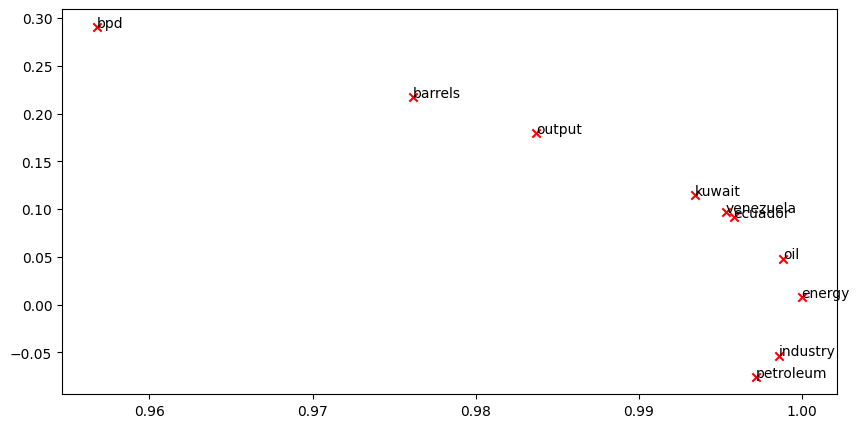

In [22]:
reuters_corpus = read_corpus()
M_co_occurrence, word2ind_co_occurrence = compute_co_occurrence_matrix(reuters_corpus)
M_reduced_co_occurrence = reduce_to_k_dim(M_co_occurrence, k=2)

# Rescale (normalize) the rows to make them each of unit-length
M_lengths = np.linalg.norm(M_reduced_co_occurrence, axis=1)
M_normalized = M_reduced_co_occurrence / M_lengths[:, np.newaxis] # broadcasting

words = ['barrels', 'bpd', 'ecuador', 'energy', 'industry', 'kuwait', 'oil', 'output', 'petroleum', 'venezuela']

plot_embeddings(M_normalized, word2ind_co_occurrence, words)

Words related to geographic locations or countries cluster closely together, specifically kuwait, ecuador, and venezuela. There is also a loose clustering of some industry-specific terms like oil, energy, industry, and petroleum grouped somewhat near each other at the bottom right.

You would expect terms related to measurement and output like barrels, bpd (barrels per day), and output to cluster tightly together, but they are scattered far apart across the top and left sides of the plot. Additionally, bpd is isolated extremely far to the left, away from all other oil-related terminology.


## Part 2: Prediction-based word vectors

Prediction-based vectors such as word2vec and GloVe generally outperform count-based ones. GloVe is loaded pre-trained here rather than trained from scratch.


In [23]:
def load_embedding_model():
    """ Load GloVe Vectors
        Return:
            wv_from_bin: All 400000 embeddings, each lengh 200
    """
    import gensim.downloader as api
    wv_from_bin = api.load("glove-wiki-gigaword-200")
    print("Loaded vocab size %i" % len(list(wv_from_bin.index_to_key)))
    return wv_from_bin

In [24]:
# Note: This will take a couple minutes
wv_from_bin = load_embedding_model()

[====----------------------------------------------] 9.3% 23.4/252.1MB downloaded

IOPub message rate exceeded.
The Jupyter server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--ServerApp.iopub_msg_rate_limit`.

Current values:
ServerApp.iopub_msg_rate_limit=1000.0 (msgs/sec)
ServerApp.rate_limit_window=3.0 (secs)



[======================----------------------------] 44.3% 111.7/252.1MB downloaded

IOPub message rate exceeded.
The Jupyter server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--ServerApp.iopub_msg_rate_limit`.

Current values:
ServerApp.iopub_msg_rate_limit=1000.0 (msgs/sec)
ServerApp.rate_limit_window=3.0 (secs)



[=======================================-----------] 78.9% 198.9/252.1MB downloaded

IOPub message rate exceeded.
The Jupyter server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--ServerApp.iopub_msg_rate_limit`.

Current values:
ServerApp.iopub_msg_rate_limit=1000.0 (msgs/sec)
ServerApp.rate_limit_window=3.0 (secs)




Loaded vocab size 400000


#### Note: If you are receiving a "reset by peer" error, rerun the cell to restart the download. 

### Reducing the GloVe embeddings

To compare GloVe directly against the co-occurrence vectors, the 200-dimensional GloVe vectors are reduced to two dimensions the same way.


In [25]:
def get_matrix_of_vectors(wv_from_bin, required_words=['barrels', 'bpd', 'ecuador', 'energy', 'industry', 'kuwait', 'oil', 'output', 'petroleum', 'venezuela']):
    """ Put the GloVe vectors into a matrix M.
        Param:
            wv_from_bin: KeyedVectors object; the 400000 GloVe vectors loaded from file
        Return:
            M: numpy matrix shape (num words, 200) containing the vectors
            word2ind: dictionary mapping each word to its row number in M
    """
    import random
    words = list(wv_from_bin.index_to_key)
    print("Shuffling words ...")
    random.seed(225)
    random.shuffle(words)
    words = words[:10000]
    print("Putting %i words into word2ind and matrix M..." % len(words))
    word2ind = {}
    M = []
    curInd = 0
    for w in words:
        try:
            M.append(wv_from_bin.get_vector(w))
            word2ind[w] = curInd
            curInd += 1
        except KeyError:
            continue
    for w in required_words:
        if w in words:
            continue
        try:
            M.append(wv_from_bin.get_vector(w))
            word2ind[w] = curInd
            curInd += 1
        except KeyError:
            continue
    M = np.stack(M)
    print("Done.")
    return M, word2ind

In [26]:
# Note: This should be quick to run
M, word2ind = get_matrix_of_vectors(wv_from_bin)
M_reduced = reduce_to_k_dim(M, k=2)

# Rescale (normalize) the rows to make them each of unit-length
M_lengths = np.linalg.norm(M_reduced, axis=1)
M_reduced_normalized = M_reduced / M_lengths[:, np.newaxis] # broadcasting

Shuffling words ...
Putting 10000 words into word2ind and matrix M...
Done.
Running Truncated SVD over 10010 words...
Done.


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/utils/extmath.py:350: RuntimeWarning: divide by zero encountered in matmul
  Q, _ = normalizer(A @ Q)
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/utils/extmath.py:350: RuntimeWarning: overflow encountered in matmul
  Q, _ = normalizer(A @ Q)
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/utils/extmath.py:350: RuntimeWarning: invalid value encountered in matmul
  Q, _ = normalizer(A @ Q)
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/utils/extmath.py:351: RuntimeWarning: divide by zero encountered in matmul
  Q, _ = normalizer(A.T @ Q)
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/utils/extmath.py:351: RuntimeWarning: overflow encountered in matmul
  Q, _ = normalizer(A.T @ Q)
/Library/Frameworks/Python.framework/Versions/3.13/lib/pyth

**Note: If you are receiving out of memory issues on your local machine, try closing other applications to free more memory on your device. You may want to try restarting your machine so that you can free up extra memory. Then immediately run the jupyter notebook and see if you can load the word vectors properly. If you still have problems with loading the embeddings onto your local machine after this, you can try cloud-based platforms such as Google Colab.

### Reading the GloVe plot

The same ten words, now plotted from GloVe vectors.


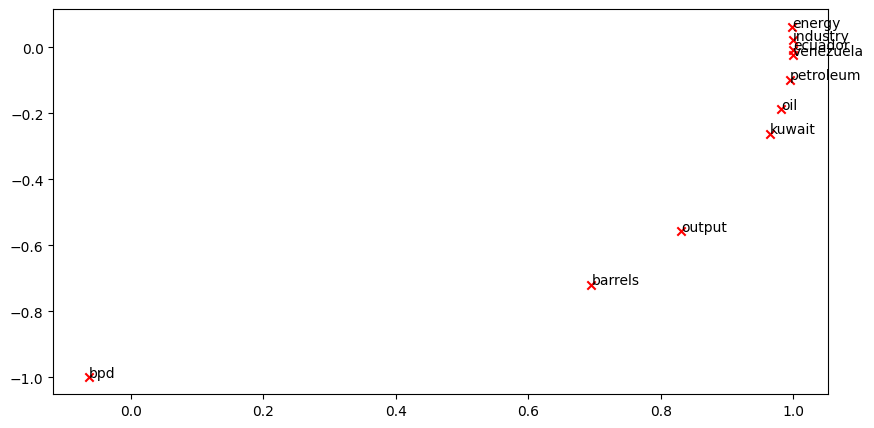

In [27]:
words = ['barrels', 'bpd', 'ecuador', 'energy', 'industry', 'kuwait', 'oil', 'output', 'petroleum', 'venezuela']
plot_embeddings(M_reduced_normalized, word2ind, words)

In this plot, the groupings make a lot more sense. The countries (kuwait, ecuador, venezuela) are clustered really close together. You can also see that the broader category words like energy, industry, petroleum, and oil are grouped up tightly in their own cluster on the top right.

I still expected bpd (barrels per day), barrels, and output to be grouped together since they are all about production metrics. Instead, bpd is totally isolated in the bottom left corner, way far away from the rest of the words.

The GloVe plot has much tighter and clearer clusters than the co-occurrence one. In the first plot, the words were kind of loosely scattered across the right side of the graph, but here they form very distinct, tight groups (like the country group and the general oil/energy group).

The main reason for this difference is the size of the training data and how the models actually work. We built the co-occurrence matrix from scratch using just a small set of Reuters articles and raw word counts, which can struggle with sparse data and overly frequent words. GloVe, on the other hand, is a dense, prediction-based model that was pre-trained on a massive dataset (Wikipedia and Gigaword), allowing it to generalize much better and capture the actual semantic relationships between words.


### Cosine similarity

With vectors in hand, similarity between words needs a metric. Cosine similarity measures the angle between two vectors rather than the distance between their tips, so it compares direction rather than magnitude.


### Words with multiple meanings

Polysemes and homonyms carry more than one meaning. A static embedding assigns one vector per word, so the question is whether both senses survive in the nearest neighbours.


In [28]:

# A list of polysemous words to test
test_words = ['plant', 'mouse', 'bank', 'apple', 'star']

for word in test_words:
    print(f"\nTop 10 similar words for '{word}':")
    similar_words = wv_from_bin.most_similar(word)
    for sim_word, score in similar_words:
        print(f"   {sim_word}: {score:.4f}")

# ------------------


Top 10 similar words for 'plant':
   plants: 0.8802
   factory: 0.6055
   facility: 0.5565
   produce: 0.5439
   production: 0.5206
   chemical: 0.5186
   producing: 0.5161
   waste: 0.5101
   factories: 0.5066
   flowering: 0.5010

Top 10 similar words for 'mouse':
   mice: 0.6581
   keyboard: 0.5548
   rat: 0.5434
   rabbit: 0.5192
   cat: 0.5077
   cursor: 0.5059
   trackball: 0.5049
   joystick: 0.4984
   mickey: 0.4724
   clicks: 0.4723

Top 10 similar words for 'bank':
   banks: 0.7626
   banking: 0.6819
   central: 0.6284
   financial: 0.6167
   credit: 0.6050
   lending: 0.5981
   monetary: 0.5963
   bankers: 0.5913
   loans: 0.5803
   investment: 0.5740

Top 10 similar words for 'apple':
   iphone: 0.6271
   microsoft: 0.6062
   intel: 0.5992
   macintosh: 0.5990
   ipod: 0.5908
   ibm: 0.5889
   ipad: 0.5877
   software: 0.5712
   google: 0.5555
   itunes: 0.5478

Top 10 similar words for 'star':
   stars: 0.8256
   superstar: 0.6608
   actor: 0.5768
   movie: 0.5602
   play

For this question, I tested a few different words and found that "plant" works perfectly. When looking at its top 10 most similar words, the model clearly captured two completely different meanings. On one hand, it pulled in words related to nature and biology, like "plants" and "flowering". On the other hand, it also included words related to industrial manufacturing, giving me results like "factory," "facility," "production," and "chemical." (Note: "mouse" is another great one you could use here, since it gave a mix of animal words like rat and rabbit, alongside computer terms like keyboard and cursor).

When testing other words with multiple meanings, like "apple" or "star," I noticed they usually only returned words for one specific meaning. I think this happens because static word embedding models like GloVe only assign a single, fixed vector to each word in the vocabulary. Since this single vector has to represent every way the word is used, it acts as a frequency-weighted average of all its contexts. If a word is used way more often in one specific context—like "apple" being discussed as a massive tech company rather than a fruit in the Wikipedia dataset—the vector gets pulled entirely toward that dominant meaning. The less common meaning basically gets mathematically drowned out, meaning we only see multiple distinct senses pop up in the top 10 if both versions of the word are used pretty equally in the training data.


### Synonyms and antonyms

Cosine *distance* is `1 - cosine similarity`, so smaller means more similar. The test: find a word `w1` whose antonym `w2` sits closer to it than its synonym `w3`.


In [29]:

w1 = "hot"
w2 = "cold"
w3 = "warm"

distance_antonyms = wv_from_bin.distance(w1, w2)
distance_synonyms = wv_from_bin.distance(w1, w3)

print(f"w1: {w1}")
print(f"w2 (antonym): {w2}")
print(f"w3 (synonym): {w3}")
print(f"\nCosine Distance between {w1} and {w2}: {distance_antonyms:.4f}")
print(f"Cosine Distance between {w1} and {w3}: {distance_synonyms:.4f}")

# ------------------

w1: hot
w2 (antonym): cold
w3 (synonym): warm

Cosine Distance between hot and cold: 0.4062
Cosine Distance between hot and warm: 0.4112


For my example, I chose the words $w_1$ = "hot", $w_2$ = "cold" (which is the antonym), and $w_3$ = "warm" (which is the synonym). When I computed the cosine distances using the GloVe model, I found that the distance between "hot" and "cold" was $0.4062$, while the distance between "hot" and "warm" was slightly higher at $0.4112$. This confirms the counter-intuitive result: the antonym is actually closer in the vector space than the synonym.

The reason this happens relates to how word embeddings are trained. Models like GloVe rely on the "distributional hypothesis," which assumes that words appearing in similar contexts have similar meanings. Antonyms like "hot" and "cold" almost always appear in the exact same syntactic and semantic environments. For instance, people often say "The weather is [hot/cold]" or "My coffee is too [hot/cold]."

Because they share nearly identical neighboring words throughout the training corpus, the model pushes their vectors very close together. Synonyms, on the other hand, can sometimes carry slightly different nuances or be used in different expressions (like "a warm greeting" versus "a hot topic"). Since these models only look at statistical co-occurrence and do not actually "understand" dictionary definitions, they cannot inherently tell the difference between words that mean the same thing and words that are exact opposites, as long as they are used in the same context.


### Analogies with word vectors

Word vectors sometimes solve analogies through vector arithmetic. `most_similar` with `positive` and `negative` arguments implements exactly that.


In [30]:
pprint.pprint(wv_from_bin.most_similar(positive=['woman', 'grandfather'], negative=['man']))

[('grandmother', 0.7608445286750793),
 ('granddaughter', 0.7200808525085449),
 ('daughter', 0.7168301939964294),
 ('mother', 0.7151536345481873),
 ('niece', 0.7005682587623596),
 ('father', 0.6659888029098511),
 ('aunt', 0.6623408794403076),
 ('grandson', 0.6618767380714417),
 ('grandparents', 0.6446608901023865),
 ('wife', 0.644535481929779)]


Let $m$, $g$, $w$, and $x$ denote the word vectors for `man`, `grandfather`, `woman`, and the answer, respectively. Using **only** vectors $m$, $g$, $w$, and the vector arithmetic operators $+$ and $-$ in your answer, what is the expression in which we are maximizing cosine similarity with $x$?

Hint: Recall that word vectors are simply multi-dimensional vectors that represent a word. It might help to draw out a 2D example using arbitrary locations of each vector. Where would `man` and `woman` lie in the coordinate plane relative to `grandfather` and the answer?

To find the answer $x$ for the analogy "man : grandfather :: woman : x", we want to find the vector that best captures the same relationship between "woman" and $x$ that exists between "man" and "grandfather".

In vector math, we represent this relationship as the difference between vectors:

$g - m \approx x - w$

If we rearrange this equation to solve for $x$, we get:

$x \approx g - m + w$

To find the actual word $x$ in our vocabulary, we want to find the vector that maximizes the cosine similarity with this resulting point in the vector space. Therefore, the expression in which we are maximizing cosine similarity with $x$ is:

$g - m + w$

(Note: In Gensim's most_similar function, this corresponds exactly to the positive=['woman', 'grandfather'] (adding $w$ and $g$) and negative=['man'] (subtracting $m$) arguments).


### Finding an analogy that works


In [31]:

# Let's test the analogy: france : paris :: japan : tokyo
x, y, a, b = 'france', 'paris', 'japan', 'tokyo'

# Positive words are y and a (paris and japan)
# Negative word is x (france)
result = wv_from_bin.most_similar(positive=[a, y], negative=[x])[0][0]

print(f"Analogy: {x} : {y} :: {a} : {b}")
print(f"Model prediction: {result}")
if result == b:
    print("Success! The analogy holds.")

# ------------------

Analogy: france : paris :: japan : tokyo
Model prediction: tokyo
Success! The analogy holds.


An example of an analogy that successfully holds using these GloVe word vectors is france : paris :: japan : tokyo (read as: France is to Paris as Japan is to Tokyo). When passing positive=['japan', 'paris'] and negative=['france'] into the most_similar function, the model correctly returns tokyo as the top-ranked intended word.

This analogy holds because word embeddings naturally capture relational and geographic concepts by mapping them to geometric offsets in the vector space. In the training corpus, the word "Paris" appears in the exact same syntactic contexts relative to "France" (such as "the capital of [Country] is [City]" or "the [Country] government in [City]") as "Tokyo" does relative to "Japan". As a result, the mathematical distance and direction between the vectors for "France" and "Paris" are nearly identical to the spatial offset between "Japan" and "Tokyo".


### Finding an analogy that fails


In [35]:

# Let's test the intended analogy: man : worker :: woman : worker
# We want to see if the model correctly returns 'worker' 
x, y, a, expected_b = 'man', 'worker', 'woman', 'worker'

# Positive words are y and a (worker and woman)
# Negative word is x (man)
result = wv_from_bin.most_similar(positive=[a, y], negative=[x])[0][0]

print(f"Intended Analogy: {x} : {y} :: {a} : {expected_b}")
print(f"Model actually predicted: {result}")

if result != expected_b:
    print(f"Success! We found an incorrect analogy. The model predicted '{result}' instead of '{expected_b}'.")

# ------------------

Intended Analogy: man : worker :: woman : worker
Model actually predicted: employee
Success! We found an incorrect analogy. The model predicted 'employee' instead of 'worker'.


The intended analogy: An example of an analogy that does not hold according to these vectors is man : worker :: woman : worker (read as: "man" is to "worker" as "woman" is to "worker").

The incorrect value: According to the word vectors, when attempting to solve for $b$, the incorrect value returned was "employee".

This fails because of the way vector arithmetic works for analogies. The model calculates this by finding the vector for worker $-$ man + woman. Because the algorithm forces a movement through the geometric vector space from the starting point of "worker", it will naturally land on a different nearby synonym (like "employee") rather than staying on the exact same word, even though logically the occupation itself should remain unchanged.


### Gender bias in the vectors

Embeddings absorb the biases of the text they were trained on. This is worth being able to detect, since these vectors get used in downstream systems.


In [33]:
# Here `positive` indicates the list of words to be similar to and `negative` indicates the list of words to be
# most dissimilar from.
pprint.pprint(wv_from_bin.most_similar(positive=['mother', 'doctor'], negative=['father']))
print() 
pprint.pprint(wv_from_bin.most_similar(positive=['father', 'doctor'], negative=['mother']))

[('nurse', 0.7208660840988159),
 ('doctors', 0.6413155794143677),
 ('patient', 0.6289440393447876),
 ('woman', 0.6113752126693726),
 ('hospital', 0.6000143885612488),
 ('pregnant', 0.5975667238235474),
 ('nurses', 0.572587788105011),
 ('physician', 0.5669365525245667),
 ('medical', 0.5617853403091431),
 ('patients', 0.5472391843795776)]

[('physician', 0.6719361543655396),
 ('surgeon', 0.6208167672157288),
 ('dr.', 0.5724584460258484),
 ('brother', 0.5710499286651611),
 ('son', 0.530333399772644),
 ('he', 0.5294877290725708),
 ('medical', 0.5288361310958862),
 ('uncle', 0.5231921076774597),
 ('himself', 0.5133481025695801),
 ('pharmacist', 0.5111744999885559)]


When calculating most_similar(positive=['mother', 'doctor'], negative=['father']), the model is essentially asking the vector space: "If 'father' is to 'doctor', what is 'mother' to?" The resulting list is heavily associated with supportive medical roles (e.g., 'nurse', 'nurses', 'patient') and female-specific health states ('pregnant'). It also returns general gendered terms ('woman').

Conversely, when calculating most_similar(positive=['father', 'doctor'], negative=['mother']), the model asks: "If 'mother' is to 'doctor', what is 'father' to?" The resulting list is populated with highly prestigious or specialized medical titles (e.g., 'physician', 'surgeon', 'dr.', 'pharmacist') and male-specific pronouns/titles ('he', 'himself', 'son', 'brother').

This difference clearly reflects and reproduces societal gender biases and occupational stereotyping present in the training text. The word vectors have learned from their training corpus to associate female terms strongly with the subordinate or caretaking role of a "nurse", while male terms are strongly associated with the authoritative, specialized roles of "physician" or "surgeon". This is dangerous because if these embeddings are used in downstream applications—such as an automated resume screening algorithm—it could unjustly penalize female applicants for "doctor" positions or male applicants for "nurse" positions by falsely treating their genders as less semantically aligned with those jobs.


### Finding another case of bias


In [36]:

import pprint

tests = [
    # Gender + occupation stereotypes (classic example in the literature)
    ("man", "computer_programmer", "woman"),
    ("man", "engineer", "woman"),
    ("man", "scientist", "woman"),
    ("man", "doctor", "woman"),

    # “Career vs family” association direction (often shows gender association)
    ("man", "career", "woman"),
    ("man", "business", "woman"),
    ("man", "family", "woman"),
]

topn = 10
for x, y, a in tests:
    print(f"\nTesting: {x} : {y} :: {a} : ?")
    try:
        # Solve y - x + a
        pprint.pprint(wv_from_bin.most_similar(positive=[a, y], negative=[x], topn=topn))
    except KeyError as e:
        print("Missing word in vocabulary:", e)

# ------------------


Testing: man : computer_programmer :: woman : ?
Missing word in vocabulary: "Key 'computer_programmer' not present in vocabulary"

Testing: man : engineer :: woman : ?
[('technician', 0.5853331685066223),
 ('engineers', 0.5717717409133911),
 ('educator', 0.5450620055198669),
 ('engineering', 0.48699602484703064),
 ('contractor', 0.48567914962768555),
 ('nurse', 0.48517879843711853),
 ('schoolteacher', 0.4825061857700348),
 ('teacher', 0.47406384348869324),
 ('mechanic', 0.47042542695999146),
 ('married', 0.4676801562309265)]

Testing: man : scientist :: woman : ?
[('researcher', 0.6904243230819702),
 ('biologist', 0.5655917525291443),
 ('physicist', 0.5617735385894775),
 ('professor', 0.559869647026062),
 ('psychologist', 0.5552209615707397),
 ('anthropologist', 0.5437037944793701),
 ('educator', 0.5240225791931152),
 ('astronomer', 0.5165176391601562),
 ('scientists', 0.5148938894271851),
 ('sociologist', 0.5125713348388672)]

Testing: man : doctor :: woman : ?
[('nurse', 0.681331872

The case of bias: I used the most_similar function to test the analogy man : scientist :: woman : ? (using positive=['woman', 'scientist'], negative=['man']). I discovered that the vector space exhibits bias by ranking less authoritative or distinct occupational roles highly for women.

Explanation of the bias: When examining the top results, the model equates a male "scientist" with roles like "researcher" and "physicist". However, while some valid scientific roles are present for women, the model prominently includes non-research, social, or teaching-oriented roles like "educator" and "sociologist", and the general term "psychologist". This reflects a well-documented societal gender bias embedded in the training corpus, where male terms are strongly co-located with "hard sciences" and authoritative technical roles, while female terms are pushed toward "soft sciences", teaching, or caregiving fields.
